# 1. Problem Statement

Airline ticket prices fluctuate based on multiple factors such as the airline, departure and destination cities, travel class, journey duration, booking timing, seat availability, seasonal demand, and overall market conditions. These dynamic pricing strategies make it difficult for customers to estimate ticket costs and for airlines to optimize pricing decisions. The objective of this project is to analyze the factors influencing flight ticket prices and develop predictive models using **Linear Regression** and **Polynomial Regression** to estimate flight prices accurately. The project includes exploratory data analysis, data cleaning and preprocessing, feature engineering, model building, model evaluation using MAE, RMSE, and R² Score, and the generation of meaningful business insights. The target variable for this regression problem is **price**, which represents the flight ticket price.

# 2. Dataset Description

- The dataset contains information about domestic flight bookings and ticket prices.
- It consists of **300,453 records** and **15 features**.
- The target variable is **price**, which represents the flight ticket price.
- The dataset includes both **categorical** and **numerical** features related to flight operations and booking details.
- Categorical features include airline, flight number, source city, destination city, departure time, arrival time, number of stops, travel class, and holiday season.
- Numerical features include duration, days left before departure, flight distance, seat availability, airline rating, and price.
- To simulate a real-world business scenario, the dataset also includes a small number of missing values, duplicate records, and categorical inconsistencies for data cleaning and preprocessing.
- This dataset is suitable for exploratory data analysis, feature engineering, and building regression models to predict flight ticket prices.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("..\data\Flight_Price_Prediction_Dataset.csv")
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,flight_distance_km,seat_availability,holiday_season,airline_rating,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,1581.0,15.0,No,4.1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,1588.0,18.0,No,4.1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,1606.0,11.0,No,4.0,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,1615.0,18.0,No,4.9,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,1475.0,18.0,No,4.7,5955


Identify the Target Variable

In this project, the objective is to predict the flight ticket price.


In [4]:
print("Target Variable:", "price")

Target Variable: price


Identify Numerical and Categorical Features

The dataset contains both numerical and categorical features. 

In [5]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns.to_list()
categorical_columns = df.select_dtypes(include='object').columns.to_list()

print("Numerical Features:")
print(numerical_columns)

print("\nCategorical Features:")
print(categorical_columns)

Numerical Features:
['duration', 'days_left', 'flight_distance_km', 'seat_availability', 'airline_rating', 'price']

Categorical Features:
['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'holiday_season']


Check Dataset Shape

The shape of the dataset provides the total number of rows and columns.

In [6]:
print("Shape:", df.shape)

Shape: (300453, 15)


Check Dataset Structure


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300453 entries, 0 to 300452
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   airline             300453 non-null  str    
 1   flight              300453 non-null  str    
 2   source_city         300453 non-null  str    
 3   departure_time      300453 non-null  str    
 4   stops               300453 non-null  str    
 5   arrival_time        300453 non-null  str    
 6   destination_city    300453 non-null  str    
 7   class               300453 non-null  str    
 8   duration            299853 non-null  float64
 9   days_left           300453 non-null  int64  
 10  flight_distance_km  299853 non-null  float64
 11  seat_availability   299250 non-null  float64
 12  holiday_season      299702 non-null  str    
 13  airline_rating      299552 non-null  float64
 14  price               300453 non-null  int64  
dtypes: float64(4), int64(2), str(9)
memory usage:

checking Missing Values



In [8]:
df.isnull().sum()

airline                  0
flight                   0
source_city              0
departure_time           0
stops                    0
arrival_time             0
destination_city         0
class                    0
duration               600
days_left                0
flight_distance_km     600
seat_availability     1203
holiday_season         751
airline_rating         901
price                    0
dtype: int64

Generate Summary Statistics




In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,299853.0,12.221893,7.192710,0.83,6.83,11.25,16.17,49.83
days_left,300453.0,26.004477,13.561153,1.00,15.00,26.00,38.00,49.00
flight_distance_km,299853.0,2619.281698,444.444199,518.00,2800.00,2800.00,2800.00,2800.00
seat_availability,299250.0,56.071810,40.572966,0.00,17.00,51.00,91.00,139.00
airline_rating,299552.0,4.468190,0.324081,3.80,4.20,4.50,4.80,4.90
price,300453.0,20889.554280,22697.105558,1105.00,4783.00,7425.00,42521.00,123071.00


Price Distribution

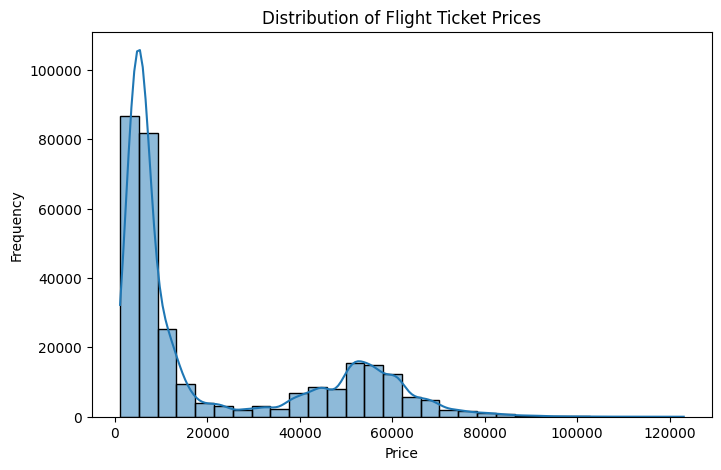

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'],bins=30,kde=True)
plt.title("Distribution of Flight Ticket Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


boxplot of price

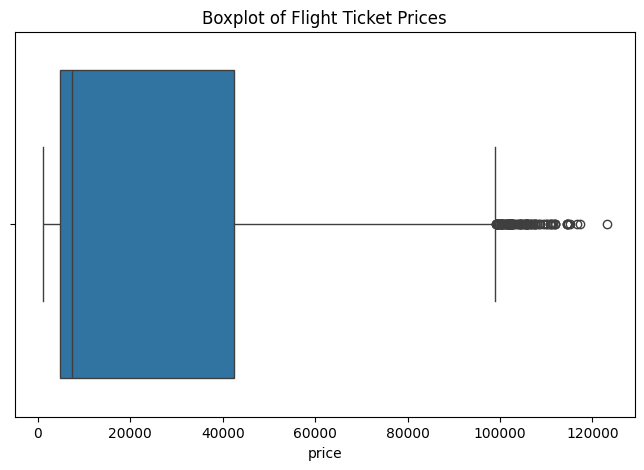

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["price"])
plt.title("Boxplot of Flight Ticket Prices")
plt.show()

Duration vs Price

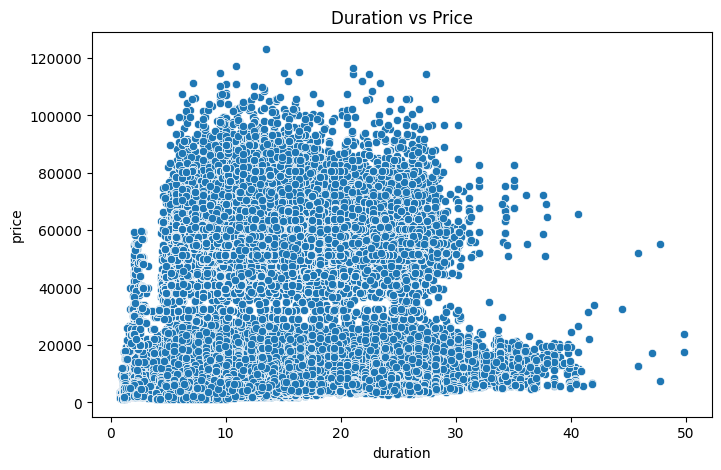

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['duration'],y=df['price'])
plt.title("Duration vs Price")
plt.show()

Correlation Heatmap

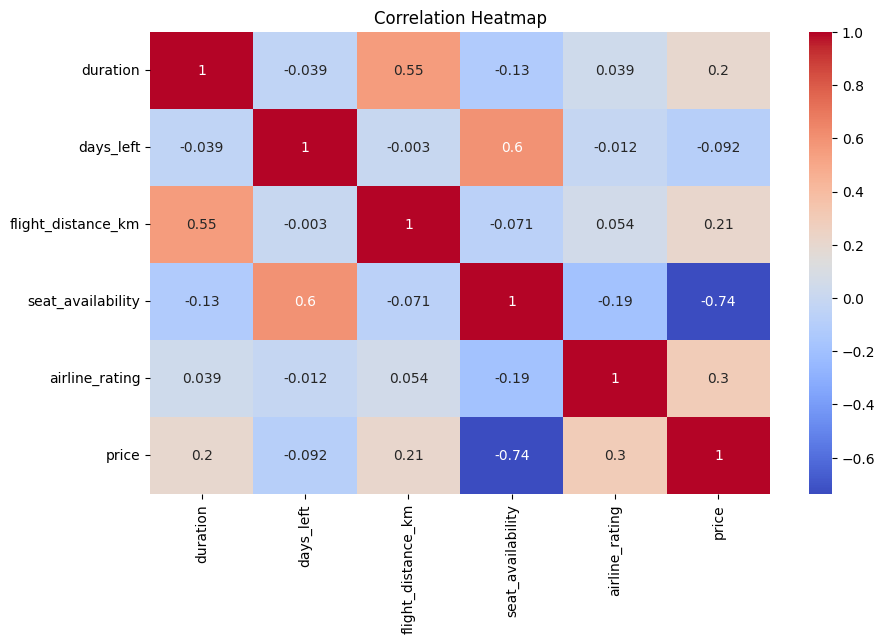

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap( 
    df.corr(numeric_only=True),
    annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

Price by Travel Class

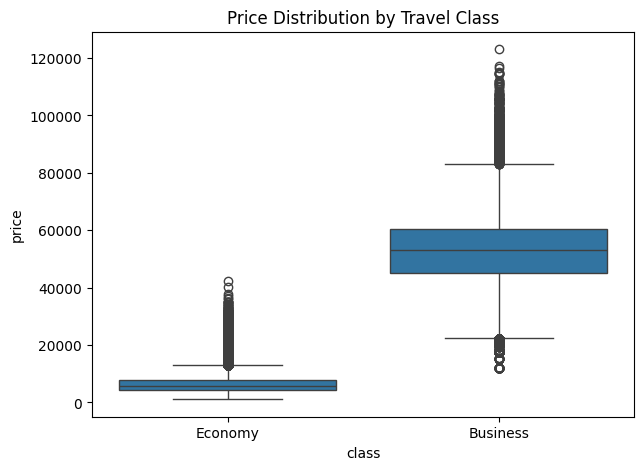

In [14]:
plt.figure(figsize=(7,5))
sns.boxplot( data=df, x="class", y="price" )
plt.title("Price Distribution by Travel Class")

plt.show()

Number of Stops

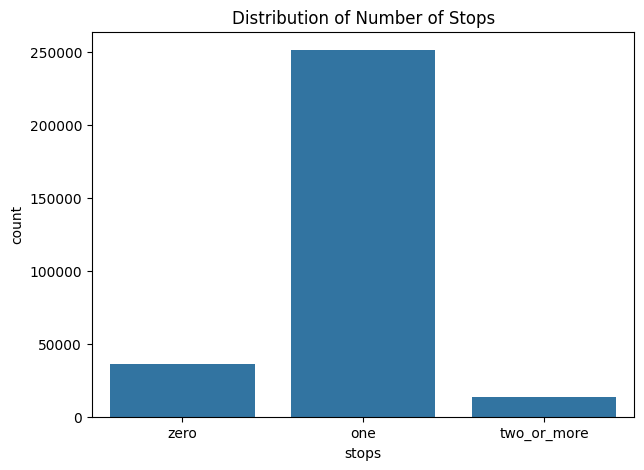

In [15]:
plt.figure(figsize=(7,5))
sns.countplot( data=df, x="stops" ) 
plt.title("Distribution of Number of Stops") 

plt.show()

Flight Distance vs Price

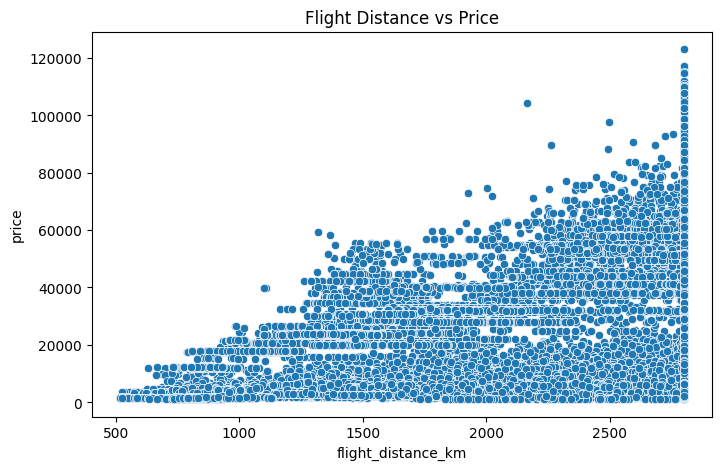

In [16]:
plt.figure(figsize=(8,5)) 
sns.scatterplot(x=df["flight_distance_km"], y=df["price"])
plt.title("Flight Distance vs Price")

plt.show()

# EDA Summary

## What the Dataset Represents

This dataset represents domestic flight booking information and airline ticket prices. It contains flight-related features such as airline, source and destination cities, departure and arrival times, number of stops, travel class, journey duration, booking lead time, and ticket price. Additional business-oriented features, including flight distance, seat availability, holiday season, and airline rating, were engineered to better simulate a real-world airline pricing scenario. The primary objective of this dataset is to analyze the factors affecting flight ticket prices and develop regression models for price prediction.

---

## Variable Being Predicted

The target variable in this project is **`price`**, which represents the flight ticket price. Since the target variable is continuous, this is a **regression problem**. The goal is to predict the ticket price based on the available flight and booking features.

---

## Key Patterns Discovered

From the initial exploratory data analysis, the following key patterns were observed:

- Flight ticket prices are **positively skewed**, with most tickets concentrated in the lower price range and a smaller number of premium-priced tickets.
- The boxplot reveals several high-priced observations, which appear to be genuine premium fares rather than data errors.
- Journey **duration** shows a positive relationship with ticket price, indicating that longer journeys generally tend to cost more.
- **Flight distance** also has a positive relationship with price, although other factors such as travel class and airline contribute to price variation.
- The correlation heatmap shows that **seat availability** has the strongest negative correlation with ticket price, suggesting that flights with fewer available seats tend to be more expensive.
- **Airline rating**, **flight distance**, and **duration** have moderate positive correlations with ticket price.
- Business-class flights have significantly higher ticket prices than economy-class flights.
- One-stop flights are the most common in the dataset, while two-or-more-stop flights occur less frequently.


These findings provide a strong foundation for the next phase of the project, where the dataset will be cleaned, preprocessed, and prepared for regression model development.

# Data Cleaning & Preprocessing

In this section, the dataset is examined and cleaned to improve its quality and prepare it for further analysis and modeling.

## Handle Missing Values

In [17]:
df.isnull().sum()

airline                  0
flight                   0
source_city              0
departure_time           0
stops                    0
arrival_time             0
destination_city         0
class                    0
duration               600
days_left                0
flight_distance_km     600
seat_availability     1203
holiday_season         751
airline_rating         901
price                    0
dtype: int64

In [18]:
# Fill numerical columns with median

df['duration'] = df['duration'].fillna(df['duration'].median())
df['flight_distance_km'] = df['flight_distance_km'].fillna(df['flight_distance_km'].median())
df['seat_availability'] = df['seat_availability'].fillna(df['seat_availability'].median())
df['airline_rating'] = df['airline_rating'].fillna(df['airline_rating'].median())

# Fill categorical column with mode

df['holiday_season'] = df['holiday_season'].fillna(df['holiday_season'].mode()[0])

df.isnull().sum()


airline               0
flight                0
source_city           0
departure_time        0
stops                 0
arrival_time          0
destination_city      0
class                 0
duration              0
days_left             0
flight_distance_km    0
seat_availability     0
holiday_season        0
airline_rating        0
price                 0
dtype: int64

## Remove Duplicate Records

In [19]:
df.duplicated().sum()

np.int64(235)

In [20]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

df.duplicated().sum()

np.int64(0)

## Fix Inconsistent Values

In [21]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())



airline
<StringArray>
[ 'SpiceJet',   'AirAsia',   'Vistara',  'GO_FIRST',    'Indigo', 'Air_India',
  'Go First', 'Air India',   'VISTARA',   'airasia',    'indigo', 'Spice Jet']
Length: 12, dtype: str

flight
<StringArray>
['SG-8709', 'SG-8157',  'I5-764',  'UK-995',  'UK-963',  'UK-945',  'UK-927',
  'UK-951',  'G8-334',  'G8-336',
 ...
  '6E-804', '6E-7183', 'SG-6017', '6E-7208', '6E-7252', '6E-7141',  '6E-557',
 '6E-7127', '6E-7259',  'AI-433']
Length: 1561, dtype: str

source_city
<StringArray>
['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
Length: 6, dtype: str

departure_time
<StringArray>
['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night', 'Late_Night']
Length: 6, dtype: str

stops
<StringArray>
['zero', 'one', 'two_or_more']
Length: 3, dtype: str

arrival_time
<StringArray>
['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening', 'Late_Night']
Length: 6, dtype: str

destination_city
<StringArray>
['Mumbai', 'Bangalore', 'Kolkata', 'Hyderab

In [22]:
df["airline"] = df["airline"].replace({
    "Air India": "Air_India",
    "Go First": "GO_FIRST",
    "indigo": "Indigo",
    "VISTARA": "Vistara",
    "airasia": "AirAsia",
    "Spice Jet": "SpiceJet"
})

df["holiday_season"] = df["holiday_season"].replace({
    "YES": "Yes",
    "yes": "Yes",
    "Y": "Yes",
    "NO": "No",
    "no": "No",
    "N": "No"
})

print(df["airline"].unique())
print(df["holiday_season"].unique())

<StringArray>
['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo', 'Air_India']
Length: 6, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


## Convert Data Types

In [23]:
df.dtypes

airline                   str
flight                    str
source_city               str
departure_time            str
stops                     str
arrival_time              str
destination_city          str
class                     str
duration              float64
days_left               int64
flight_distance_km    float64
seat_availability     float64
holiday_season            str
airline_rating        float64
price                   int64
dtype: object

In [24]:
df["seat_availability"] = df["seat_availability"].astype(int)
df.dtypes

airline                   str
flight                    str
source_city               str
departure_time            str
stops                     str
arrival_time              str
destination_city          str
class                     str
duration              float64
days_left               int64
flight_distance_km    float64
seat_availability       int64
holiday_season            str
airline_rating        float64
price                   int64
dtype: object

## Detect Outliers

In [53]:
for col in ["duration","days_left","seat_availability","airline_rating","price"]:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col)
    print("Outliers:", len(outliers))
    print('')
    

duration
Outliers: 2107

days_left
Outliers: 0

seat_availability
Outliers: 0

airline_rating
Outliers: 0

price
Outliers: 123



## Remove Unwanted column

In [33]:
df.drop("flight", axis=1, inplace=True)

## Categorical Encoding

In [ ]:
# label encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["holiday_season"] = le.fit_transform(df["holiday_season"])


In [39]:
# one hot encoding

df = pd.get_dummies(df,columns=[
    "airline",
    'source_city',
    "departure_time",
    "stops",
    "arrival_time",
    "destination_city",
    "class"],
    drop_first=True,dtype=int)

In [50]:
print(df.info())
df.head(5)


<class 'pandas.DataFrame'>
RangeIndex: 300218 entries, 0 to 300217
Data columns (total 35 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   duration                      300218 non-null  float64
 1   days_left                     300218 non-null  int64  
 2   flight_distance_km            300218 non-null  float64
 3   seat_availability             300218 non-null  int64  
 4   holiday_season                300218 non-null  int64  
 5   airline_rating                300218 non-null  float64
 6   price                         300218 non-null  int64  
 7   airline_Air_India             300218 non-null  int64  
 8   airline_GO_FIRST              300218 non-null  int64  
 9   airline_Indigo                300218 non-null  int64  
 10  airline_SpiceJet              300218 non-null  int64  
 11  airline_Vistara               300218 non-null  int64  
 12  source_city_Chennai           300218 non-null  int64  


,duration,days_left,flight_distance_km,seat_availability,holiday_season,airline_rating,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,2.17,1,1581.0,15,0,4.1,5953,0,0,0,...,0,0,0,1,0,0,0,0,1,1
1,2.33,1,1588.0,18,0,4.1,5953,0,0,0,...,0,0,1,0,0,0,0,0,1,1
2,2.17,1,1606.0,11,0,4.0,5956,0,0,0,...,0,0,0,0,0,0,0,0,1,1
3,2.25,1,1615.0,18,0,4.9,5955,0,0,0,...,0,0,0,0,0,0,0,0,1,1
4,2.33,1,1475.0,18,0,4.7,5955,0,0,0,...,0,0,1,0,0,0,0,0,1,1


## Issues Found in the Dataset

The following issues were identified during the data cleaning process:

- Missing values were found in the `duration`, `flight_distance_km`, `seat_availability`, `holiday_season`, and `airline_rating` columns.
- A small number of duplicate records were present in the dataset.
- Inconsistent values were identified in the `airline` and `holiday_season` columns due to differences in naming and capitalization.
- Potential outliers were detected in the `duration` and `price` columns.
- The `flight` column was identified as a high-cardinality identifier that was not suitable for machine learning.

## Cleaning Decisions Made

The following preprocessing steps were performed to improve the quality of the dataset:

- Missing values in numerical columns were replaced using the median.
- Missing values in the `holiday_season` column were replaced using the mode.
- Duplicate records were removed from the dataset.
- Inconsistent categorical values were standardized using the `replace()` function.
- The `seat_availability` column was converted from `float` to `int`.
- Outliers were identified using the IQR method but were retained because they represent realistic flight booking scenarios.
- The `flight` column was removed before model building because it is an identifier and does not contribute significantly to price prediction.
- Label Encoding was applied to the `holiday_season` column.
- One-Hot Encoding was applied to the remaining categorical features.

## Assumptions Taken During Preprocessing

The following assumptions were made during preprocessing:

- Missing values occurred randomly and could be safely imputed using statistical methods.
- Duplicate rows represented repeated records and were removed.
- Different spellings and capitalization of categorical values represented the same category and were standardized.
- The detected outliers were considered genuine observations rather than data entry errors and were therefore retained.
- The `flight` column was treated as an identifier and excluded from model training.
- Label Encoding was appropriate for the binary `holiday_season` feature, while One-Hot Encoding was used for categorical features with multiple categories.